__Задача 2__: Разработка системы детектирования объектов на основе нейронной сети Faster R-CNN 

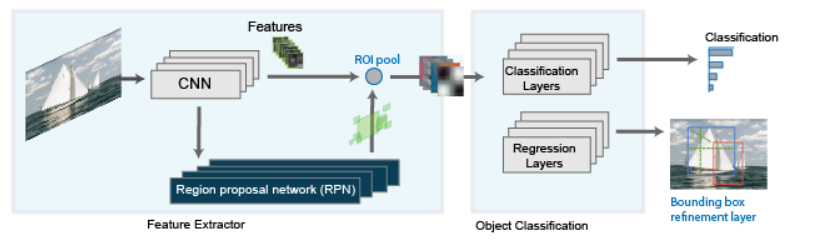

Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks   
Shaoqing Ren, Kaiming He, Ross Girshick, and Jian Sun   
6 Jan 2016   
    
https://arxiv.org/pdf/1506.01497.pdf

---

In [4]:
import os
import numpy as np
from numpy import random as rng
from PIL import Image
from PIL import ImageDraw
from matplotlib import pyplot as plt

In [5]:
import torch
import torchvision
from torchvision import transforms

## подгружаем предобученую модель  Faster R-CNN

In [3]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn

model = fasterrcnn_resnet50_fpn(pretrained=True) 
model = model.train(mode=False)

/opt/venv/jupyter_3.9_1/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/venv/jupyter_3.9_1/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
# model

In [5]:
# COCO_INSTANCE_CATEGORY_NAMES = [
#     '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
#     'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
#     'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
#     'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
#     'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
#     'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
#     'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
#     'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
#     'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
#     'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
#     'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
#     'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
# ]

## выполняем детекцию

In [6]:
# !ls ../data/vehicleImages

In [7]:
folder_img = '../data/vehicleImages' # папка с картинками для распознавания
folder_result = 'result/lab_02/' # папка с картинками размеченными моделью

In [8]:
# список файлов с картинками
files = [ f for f in os.listdir(folder_img) if f[-4:]=='.jpg' ]
display(len(files))

295

In [14]:
import pandas as pd

In [15]:
def file_proc( f, folder_result=folder_result, class_idx=3, score_thr=0.7):
    img = Image.open(f)
    x = transforms.ToTensor()(img).unsqueeze(dim=0) # преобразуем фото в torch.tensor
    with torch.no_grad():  # отключаем расчёт градиента
        o = model(x)  # считаем выход модели

    # извлекаем результаты
    boxes = o[0]['boxes'].detach().numpy() # рамки объектов
    scores = o[0]['scores'].detach().numpy() # скор класса-результата
    labels = o[0]['labels'].detach().numpy() # метка класса
    # формируем имя объекта со скором
    text = [ '%.2f'%( scores[n] ) for n in range(len(labels)) ]

    # рисуем результат
    res = img.copy()
    res_draw = ImageDraw.Draw(res)
    res_box = []
    for n in range(len(labels)): # для всех найденых объектов
        if labels[n]!=class_idx: continue  # только выбранный класс (машинки)
        if scores[n]<score_thr: continue # выкидываем объекты с низким скором
        fx0,fy0,fx1,fy1 = boxes[n,:].tolist() # координаты углов рамки объекта
        res_draw.rectangle( (fx0,fy0,fx1,fy1), outline='red' ) # рисуем рамку

        # подписываем
        tfp = fx0,fy0-10,fx1,fy0   # координаты рамки заголовка
        res_draw.rectangle(tfp,fill='red')
        tx,ty = fx0,fy0-10 # координаты подписи
        res_draw.text((tx,ty),text[n],fill='white')
        
        res_box.append( boxes[n,:].tolist()+ [ scores[n] ]) 

    
    fr = folder_result+'/'+os.path.basename(f)
    res.save(fr)
    pd.DataFrame(res_box).to_csv(fr[:-4]+'.tsv', index=False,header=False,sep='\t')

In [17]:
from tqdm.auto import tqdm

for f in tqdm( files ): file_proc( folder_img+'/'+f )

  0%|          | 0/295 [00:00<?, ?it/s]

## результаты 

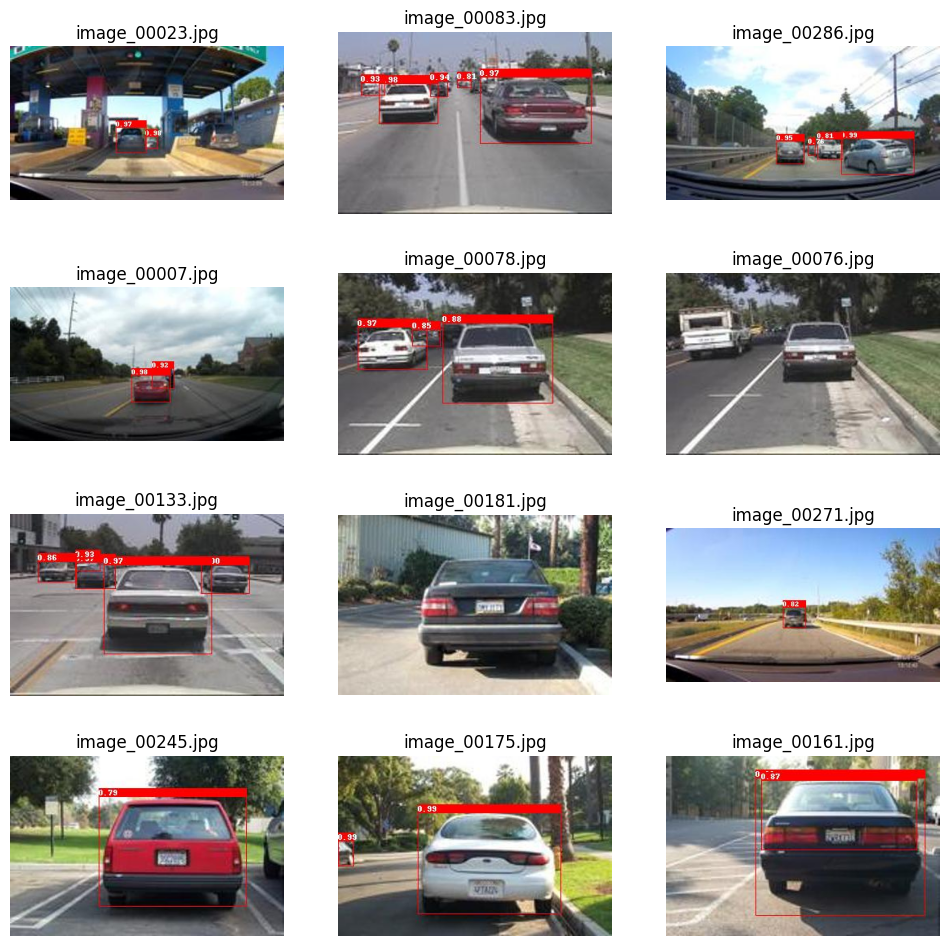

In [21]:
from numpy import random as rng

n_show = 12 # количество примеров 
n_cols = 3 # количество колонок
n_rows = np.ceil(n_show/n_cols).astype(int) # количество строк

plt.figure(figsize=(12,n_rows*3))
for n,f in enumerate(rng.permutation(files)[:n_show]):
    img = Image.open(folder_result+'/'+f)
    plt.subplot( n_rows, n_cols, n+1)
    plt.axis(False)
    plt.title(f)
    plt.imshow(img)

In [18]:
# from matplotlib import pyplot as plt